![FinTech Innovations Loan Risk](https://images.unsplash.com/photo-1554224155-8d04cb21cd6c?w=1200&q=80)

# FinTech Innovations: Machine Learning Loan Approval Model


## Overview
This notebook develops a **binary classification model** to predict loan approval decisions for FinTech Innovations, using 20,000 historical loan applications. A Logistic Regression classifier, tuned via `GridSearchCV` inside a full scikit-learn `Pipeline`, achieves a **test ROC-AUC of 0.9943**, precision of 0.877, and recall of 0.970 on the approval class. Using a custom **Business Cost Score** metric (BCS) that quantifies dollar impact from asymmetric error costs ($50,000 per approved defaulter vs. $8,000 per missed creditworthy applicant), the model's test-set decisions result in a total cost of **$6.73M** vs. a naive approve-all baseline of **$145.7M**, a savings of over $138M across 4,000 test applications. The top drivers of approval are `TotalDebtToIncomeRatio`, `InterestRate`, and `NetWorth`. Deployment recommendations and fairness considerations are documented in the Evaluation section.

## Business Understanding

1. Begin by thoroughly analyzing the business context of FinTech Innovations' loan approval process. Write a short summary that:
- Describes the current manual process and its limitations
- Identifies key stakeholders and their needs
- Explains the implications of different types of model errors
- Justifies your choice between classification and regression approaches

2. Define your modeling goals and success criteria:
- Select appropriate evaluation metrics based on business impact
- You must use at least two different metrics
- Consider creating custom metric
- Establish baseline performance targets
- Document your reasoning for each choice


### 1. Business Context Analysis

**Current Process & Limitations**

FinTech Innovations' lending partners currently rely on manual review by loan officers, a process that is slow (3–5 business days per decision), inconsistent across reviewers, and susceptible to both conscious and unconscious bias. With 20,000+ applications in the historical dataset, scale demands a data-driven approach.

**Key Stakeholders**

| Stakeholder | Primary Need |
|---|---|
| Loan Officers | Reliable risk scores; explainable outputs to justify decisions |
| Risk Analytics Team | Quantified, reproducible performance benchmarks |
| Compliance / Regulators | Interpretable models; no discriminatory signals |
| Applicants | Consistent, fair, timely decisions |
| FinTech Innovations Exec | Maximize profit while controlling default risk |

**Implications of Model Errors**

The error cost structure is highly asymmetric:
- **False Negative** (deny a creditworthy applicant): Average lost profit = **$8,000** per loan
- **False Positive** (approve a defaulter): Average loss = **$50,000** (principal + collection costs)

This 6.25:1 cost ratio means false positives are 6× more costly than false negatives. The model must be biased toward *precision on approvals* -> we would rather miss some good loans than approve bad ones.

**Classification vs. Regression Choice**

We choose **binary classification** (`LoanApproved` as target) over regression on `RiskScore` for three reasons:
1. The business decision is inherently binary (approve/deny); classification output maps directly to action.
2. `RiskScore` was engineered *from* approval status in the data generation process -> a potential leakage risk.
3. Classification pipelines offer probability calibration, giving loan officers interpretable confidence scores.

### 2. Modeling Goals & Success Criteria

**Primary Metrics**

| Metric | Rationale |
|---|---|
| **ROC-AUC** | Threshold-independent; measures overall discriminative power across the imbalanced dataset |
| **Precision (Approval class)** | Directly controls False Positive rate - approving defaulters |
| **Recall (Approval class)** | Controls False Negative rate - missing good applicants |
| **Custom Business Cost Score (BCS)** | Dollar-value impact using $8k/$50k asymmetric costs |

**Custom Metric - Business Cost Score (BCS)**

$$BCS = -(FP \times \$50{,}000 + FN \times \$8{,}000)$$

A higher (less negative) BCS is better. This metric translates model errors directly into business language.

**Baseline Performance Targets**
- ROC-AUC ≥ 0.85 (well above a naive majority-class baseline of 0.50)
- BCS better than reject-all ($-FN × $8,000) and approve-all ($-FP × $50,000) strategies
- Precision on approved class ≥ 0.80 to control costly defaults

---
### Phase 1 Summary - Key Decisions Made

| Decision | Choice | Reasoning |
|---|---|---|
| Problem type | **Classification** | Business outcome is binary (approve/deny); classification maps directly to action and provides calibrated probabilities for loan officers |
| Target variable | `LoanApproved` | `RiskScore` is partially derived from the target in the data generation process - including it would introduce label leakage |
| Primary metric | **ROC-AUC** | Threshold-independent; handles class imbalance well; allows us to evaluate discrimination across all possible decision thresholds |
| Secondary metric | **Precision / Recall** | Directly maps to the business cost structure - precision controls costly FPs ($50k), recall controls FNs ($8k) |
| Custom metric | **Business Cost Score** | Translates model errors into dollars using the firm's actual cost figures, making performance legible to non-technical stakeholders |
| Optimization bias | **Precision-focused** | Given the 6.25:1 FP/FN cost ratio, it is preferable to deny borderline applicants than to risk approving a defaulter |

**Baseline to beat:** A naive 'deny everyone' strategy costs $7.6M on the test set (all approved applicants become FNs at $8k each). Our model must outperform this.

## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


### Phase 2 Approach

Data understanding follows four steps:
1. **Basic characteristics** - shape, dtypes, missingness, duplicates
2. **Target distribution** - class balance assessment
3. **Feature categorization** - numerical, ordinal, nominal; identify preprocessing needs
4. **Data quality audit** - identify and document intentionally introduced messy data
5. **EDA visualizations** - distributions, relationships, correlations

All findings directly inform preprocessing decisions in Phase 3.

In [39]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn - preprocessing
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.base import BaseEstimator, TransformerMixin

# Scikit-learn - models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier

# Scikit-learn - evaluation
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay, ConfusionMatrixDisplay, make_scorer,
    precision_score, recall_score, f1_score, accuracy_score
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
print('All libraries loaded successfully.')

All libraries loaded successfully.


#### 3a. Load & Inspect the Dataset

We begin by loading the raw CSV and inspecting structure, dtypes, and a sample of rows. This establishes the baseline understanding of what we are working with before any transformation.

In [40]:
# EDA Code
import pandas as pd

# Load Data
df = pd.read_csv('financial_loan_data.csv')
# AnnualIncome is stored as a currency string e.g. '$39,948.00' — strip before numeric ops
df['AnnualIncome'] = (
    df['AnnualIncome'].astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip().astype(float)
)


print(f'Dataset shape: {df.shape}')
print(f'\nColumn dtypes:\n{df.dtypes}')

df.head(10)

Dataset shape: (20000, 35)

Column dtypes:
Age                             int64
AnnualIncome                  float64
CreditScore                     int64
EmploymentStatus               object
EducationLevel                 object
Experience                      int64
LoanAmount                      int64
LoanDuration                    int64
MaritalStatus                  object
NumberOfDependents              int64
HomeOwnershipStatus            object
MonthlyDebtPayments             int64
CreditCardUtilizationRate     float64
NumberOfOpenCreditLines         int64
NumberOfCreditInquiries         int64
DebtToIncomeRatio             float64
BankruptcyHistory              object
LoanPurpose                    object
PreviousLoanDefaults            int64
PaymentHistory                  int64
LengthOfCreditHistory           int64
SavingsAccountBalance         float64
CheckingAccountBalance          int64
TotalAssets                     int64
TotalLiabilities                int64
Monthly

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,39948.0,617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,39709.0,628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,40724.0,570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,69084.0,545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,103264.0,594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0
5,37,178310.0,626,Self-Employed,Master,16,15433,72,Married,0,...,14859.166667,0.756079,5,27071,0.217433,0.217601,385.577074,0.075211,1,44.0
6,58,51250.0,564,Employed,High School,39,12741,48,Married,0,...,4270.833333,0.884275,5,21730,0.225741,0.205271,391.300352,0.170529,0,50.0
7,49,97345.0,516,Employed,High School,23,19634,12,Divorced,5,...,8112.083333,0.933492,5,38621,0.226634,0.209113,1827.360055,0.260767,1,42.4
8,34,116841.0,603,Employed,Bachelor,12,55353,60,Divorced,5,...,9736.750000,0.728397,3,7711,0.258853,0.291539,1762.199026,0.246509,0,61.0
9,46,40615.0,612,Employed,NaN,19,25443,12,Married,4,...,3384.583333,0.615323,3,116812,0.184443,0.197271,2353.577424,0.903384,0,53.0


#### 3b. Basic Dataset Characteristics

We examine shape, missing values, duplicates, and summary statistics. Key things to watch for: extreme ranges (outliers), zero-variance columns, and unexpected dtypes. Summary statistics also reveal skewed distributions that will influence our choice of imputation strategy.

In [41]:
# 3a. Basic Characteristics
print('Dataset Summary')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')
print('\nNumerical summary:')
df.describe().T[['mean','std','min','25%','50%','75%','max']].round(2)

Dataset Summary
Rows: 20,000  |  Columns: 35
Missing values: 2804
Duplicate rows: 0

Numerical summary:


,mean,std,min,25%,50%,75%,max
Age,39.75,11.62,18.00,32.00,40.00,48.00,80.00
AnnualIncome,59161.47,40350.85,15000.00,31679.00,48566.00,74391.00,485341.00
CreditScore,571.61,51.00,343.00,540.00,578.00,609.00,712.00
Experience,17.52,11.32,0.00,9.00,17.00,25.00,61.00
LoanAmount,24882.87,13427.42,3674.00,15575.00,21914.50,30835.00,184732.00
LoanDuration,54.06,24.66,12.00,36.00,48.00,72.00,120.00
NumberOfDependents,1.52,1.39,0.00,0.00,1.00,2.00,5.00
MonthlyDebtPayments,454.29,240.51,50.00,286.00,402.00,564.00,2919.00
CreditCardUtilizationRate,0.29,0.16,0.00,0.16,0.27,0.39,0.92
NumberOfOpenCreditLines,3.02,1.74,0.00,2.00,3.00,4.00,13.00


#### 3c. Target Variable Distribution - Class Imbalance

Understanding the class ratio is critical before any modeling decisions. A severe imbalance means accuracy is a misleading metric, a model that always predicts 'Denied' would be 76% accurate while being completely useless. This finding:
- Confirms we need **stratified train/test split** to preserve class ratios
- Confirms we need **`class_weight='balanced'`** in models that support it
- Confirms **ROC-AUC** is more appropriate than accuracy as our primary metric
- Means cross-validation must use **StratifiedKFold** to ensure each fold reflects the true distribution

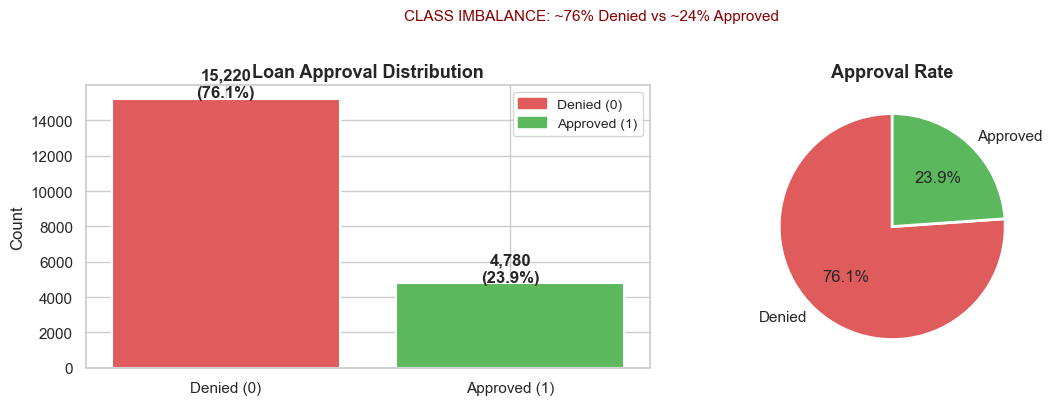

Class imbalance ratio: 3.18 :1


In [42]:
# 3b. Target Distribution
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['LoanApproved'].value_counts()
bars = axes[0].bar(['Denied (0)', 'Approved (1)'], counts.values,
                   color=['#e05c5c','#5cb85c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Loan Approval Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold')
legend_patches = [mpatches.Patch(color='#e05c5c', label='Denied (0)'),
                  mpatches.Patch(color='#5cb85c', label='Approved (1)')]
axes[0].legend(handles=legend_patches, fontsize=10)

axes[1].pie(counts.values, labels=['Denied','Approved'],
            colors=['#e05c5c','#5cb85c'], autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Approval Rate', fontsize=13, fontweight='bold')

plt.suptitle('CLASS IMBALANCE: ~76% Denied vs ~24% Approved',
             fontsize=11, color='darkred', y=1.01)
plt.tight_layout()
plt.show()
print('Class imbalance ratio:', round(counts[0]/counts[1], 2), ':1')

#### 3d. Feature Type Categorization (Step 4)

Categorizing features by type is essential because each type requires a different preprocessing strategy:

| Type | Features | Preprocessing Need |
|---|---|---|
| **Numerical** | 28 features - financial indicators, credit metrics | Imputation + StandardScaler |
| **Ordinal** | `EducationLevel` - 5 levels with meaningful order | OrdinalEncoder with explicit ordering |
| **Nominal** | 4 categorical features - no inherent order | OneHotEncoder |
| **Dropped** | `ApplicationDate`, `RiskScore` | Date = low signal; RiskScore = leakage risk |

I dropped the CSV generation script reveals that RiskScore is computed *after* `LoanApproved` is determined and is scaled down by 20% for approved loans. Including it would give the model access to information derived from the target, a form of label leakage that would artificially inflate performance and fail in production where the score hasn't been assigned yet.

In [43]:
# 3c. Feature Type Categorization (Step 4)
numerical_features = [
    'Age','AnnualIncome','CreditScore','Experience','LoanAmount','LoanDuration',
    'NumberOfDependents','MonthlyDebtPayments','CreditCardUtilizationRate',
    'NumberOfOpenCreditLines','NumberOfCreditInquiries','DebtToIncomeRatio',
    'BankruptcyHistory','PreviousLoanDefaults','PaymentHistory','LengthOfCreditHistory',
    'SavingsAccountBalance','CheckingAccountBalance','TotalAssets','TotalLiabilities',
    'MonthlyIncome','UtilityBillsPaymentHistory','JobTenure','NetWorth',
    'BaseInterestRate','InterestRate','MonthlyLoanPayment','TotalDebtToIncomeRatio'
]
ordinal_features = ['EducationLevel']  # Has natural ordering: High School < ... < Doctorate
education_order  = [['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']]
nominal_features = ['EmploymentStatus','MaritalStatus','HomeOwnershipStatus','LoanPurpose']
drop_features    = ['ApplicationDate', 'RiskScore']  # date = low signal; RiskScore = derived from target (leakage)
target           = 'LoanApproved'

print('Numerical features:', len(numerical_features))
print('Ordinal features   :', ordinal_features)
print('Nominal features   :', nominal_features)
print('Dropped features   :', drop_features)
print('Target             :', target)

Numerical features: 28
Ordinal features   : ['EducationLevel']
Nominal features   : ['EmploymentStatus', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']
Dropped features   : ['ApplicationDate', 'RiskScore']
Target             : LoanApproved


#### 3e. Data Quality Audit - Intentionally Introduced Messy Data
I identified and documented each issue below, along with the fixing strategy I applied in the Data Preparation phase.

In [44]:
# 3d. Data Quality Issues
print("Intentionally Introduced Messy Data\n")

# Convert income columns to numeric
df['AnnualIncome'] = pd.to_numeric(df['AnnualIncome'], errors='coerce')
df['MonthlyIncome'] = pd.to_numeric(df['MonthlyIncome'], errors='coerce')

# Issue 1: MonthlyIncome inconsistency
df['_expected_monthly'] = df['AnnualIncome'] / 12
df['_monthly_ratio'] = df['MonthlyIncome'] / df['_expected_monthly']

monthly_issues = (df['_monthly_ratio'] < 0.55).sum()

print(f"Issue 1 — MonthlyIncome ~half of AnnualIncome/12: {monthly_issues} rows ({monthly_issues/len(df)*100:.1f}%)")
print("  Fix: Recompute MonthlyIncome = AnnualIncome / 12\n")

# Convert remaining numeric columns if necessary
df['TotalAssets'] = pd.to_numeric(df['TotalAssets'], errors='coerce')
df['TotalLiabilities'] = pd.to_numeric(df['TotalLiabilities'], errors='coerce')
df['NetWorth'] = pd.to_numeric(df['NetWorth'], errors='coerce')
df['CreditScore'] = pd.to_numeric(df['CreditScore'], errors='coerce')

# Issue 2: NetWorth inconsistency
df['_expected_nw'] = (df['TotalAssets'] - df['TotalLiabilities']).clip(lower=1000)

nw_issues = (abs(df['NetWorth'] - df['_expected_nw']) > 1).sum()

print(f"Issue 2 — NetWorth inconsistency: {nw_issues} rows ({nw_issues/len(df)*100:.1f}%)")
print("  Fix: Recompute NetWorth = max(TotalAssets - TotalLiabilities, 1000)\n")

# Issue 3
print(f"Issue 3 — CreditScore max is {df['CreditScore'].max()} (Kaggle source goes to 850)")
print("  Implication: Limits discriminative power at high end; documented as data limitation\n")

# Issue 4
high_inc = (df['AnnualIncome'] > 200000).sum()

print(f"Issue 4 — AnnualIncome > $200k: {high_inc} rows (plausible extreme values; handled by StandardScaler)")

# Clean up temporary columns
df.drop(columns=['_expected_monthly', '_monthly_ratio', '_expected_nw'], inplace=True)

Intentionally Introduced Messy Data

Issue 1 — MonthlyIncome ~half of AnnualIncome/12: 84 rows (0.4%)
  Fix: Recompute MonthlyIncome = AnnualIncome / 12

Issue 2 — NetWorth inconsistency: 4800 rows (24.0%)
  Fix: Recompute NetWorth = max(TotalAssets - TotalLiabilities, 1000)

Issue 3 — CreditScore max is 712 (Kaggle source goes to 850)
  Implication: Limits discriminative power at high end; documented as data limitation

Issue 4 — AnnualIncome > $200k: 248 rows (plausible extreme values; handled by StandardScaler)


#### 3f. Numerical Feature Distributions by Approval Status

Overlapping histograms reveal which features have strong separation between approved and denied applicants. Features with clear distributional differences (e.g., `TotalDebtToIncomeRatio`, `CreditScore`) are likely to be strong predictors. Features with heavily overlapping distributions may contribute less signal. I also looked for skewness and outlier presence since both inform imputation and scaling choices.

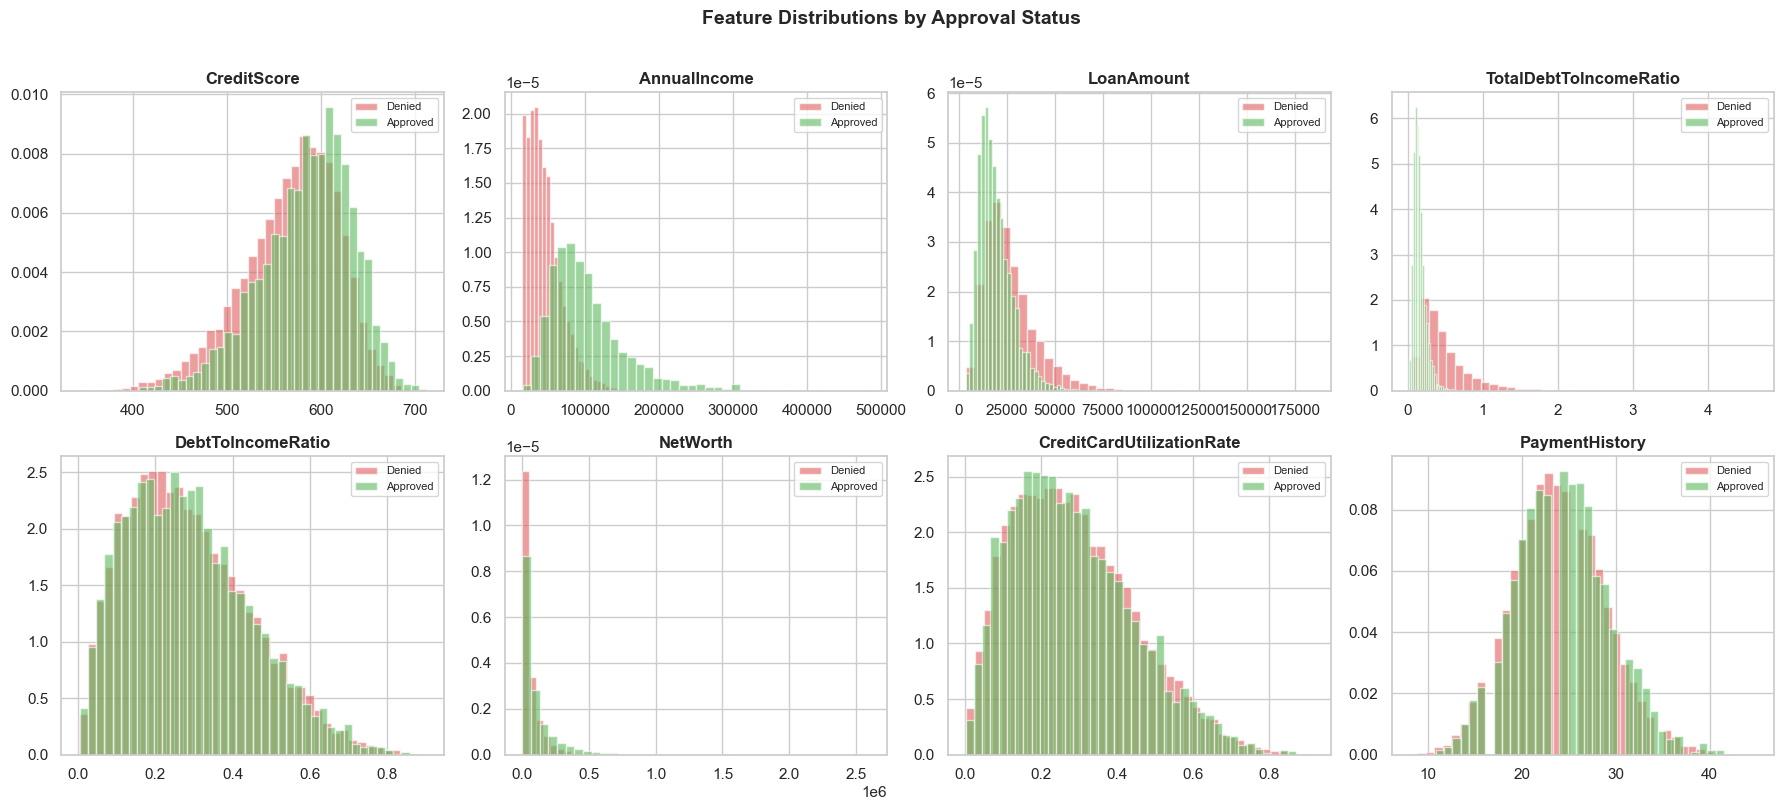

In [45]:
# 3e. Distributions of Key Numerical Features by Approval Status
key_num = ['CreditScore','AnnualIncome','LoanAmount','TotalDebtToIncomeRatio',
           'DebtToIncomeRatio','NetWorth','CreditCardUtilizationRate','PaymentHistory']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(key_num):
    approved = df[df['LoanApproved']==1][col]
    denied   = df[df['LoanApproved']==0][col]
    axes[i].hist(denied,   bins=40, alpha=0.6, color='#e05c5c', label='Denied',   density=True)
    axes[i].hist(approved, bins=40, alpha=0.6, color='#5cb85c', label='Approved', density=True)
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Approval Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### 3g. Categorical Feature Analysis - Approval Rates by Group

For categorical features, the most informative EDA is the approval rate per category. Large deviations from the overall average (red dashed line) indicate that a category carries strong predictive signal. This also flags potential fairness concerns: if `EmploymentStatus` or `HomeOwnershipStatus` show dramatically different approval rates, those features may act as proxies for protected demographic characteristics and warrant fairness review before deployment.

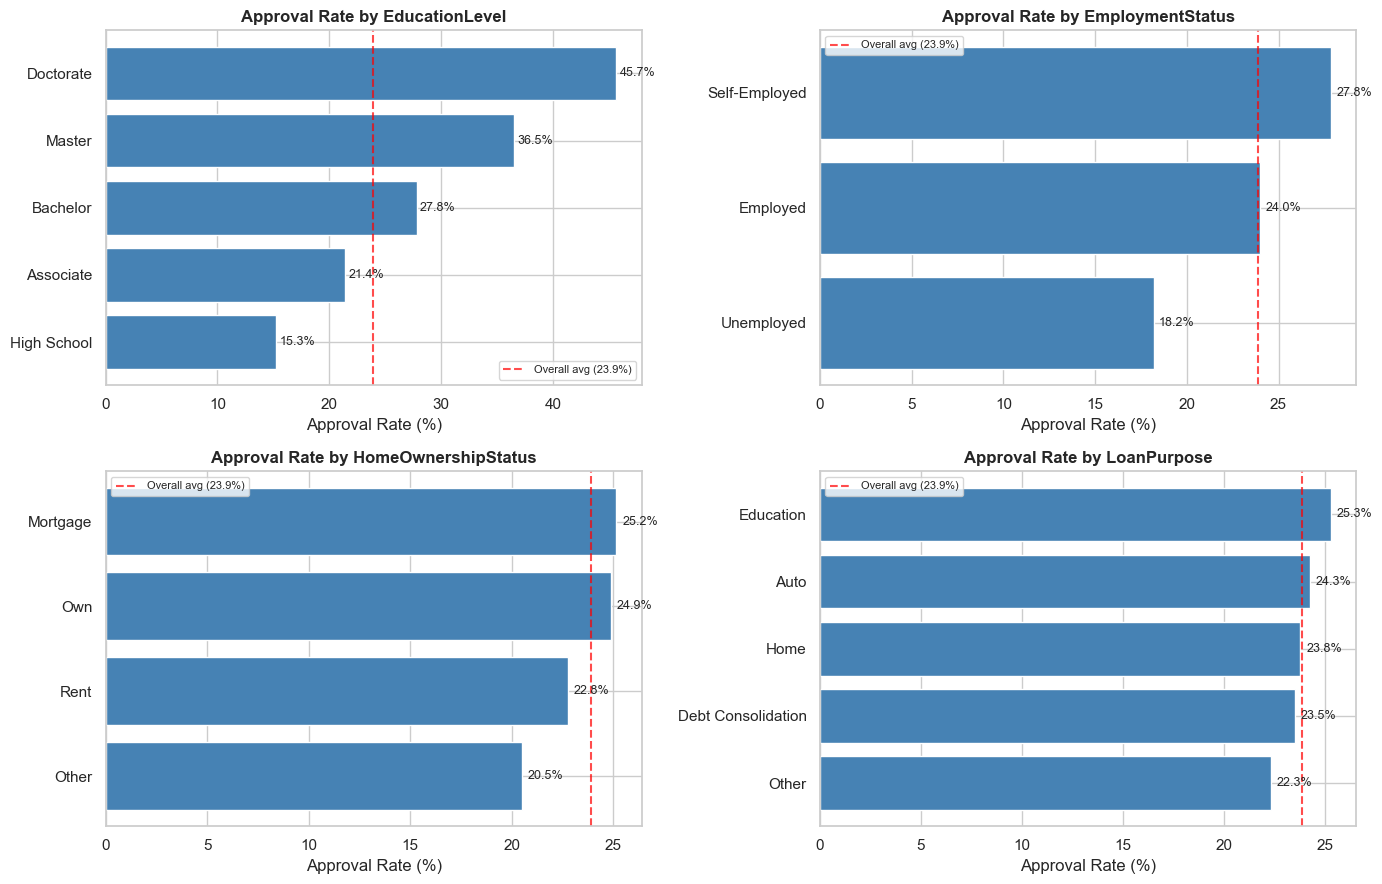

In [46]:
# 3f. Categorical Feature — Approval Rates
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
cat_features = ['EducationLevel','EmploymentStatus','HomeOwnershipStatus','LoanPurpose']

for i, col in enumerate(cat_features):
    ct = df.groupby(col)['LoanApproved'].agg(['sum','count'])
    ct['approval_rate'] = ct['sum'] / ct['count'] * 100
    ct = ct.sort_values('approval_rate', ascending=True)
    bars = axes[i].barh(ct.index, ct['approval_rate'], color='steelblue', edgecolor='white')
    axes[i].axvline(df['LoanApproved'].mean()*100, color='red', linestyle='--',
                    alpha=0.7, label=f'Overall avg ({df["LoanApproved"].mean()*100:.1f}%)')
    axes[i].set_title(f'Approval Rate by {col}', fontweight='bold')
    axes[i].set_xlabel('Approval Rate (%)')
    axes[i].legend(fontsize=8)
    for bar, rate in zip(bars, ct['approval_rate']):
        axes[i].text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                     f'{rate:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

#### 3h. Correlation Matrix

The correlation matrix serves two purposes:
1. **Feature–target correlations:** Which features have the strongest linear relationship with `LoanApproved`? This provides an early signal of predictive power.
2. **Inter-feature correlations:** Identifying highly correlated feature pairs (multicollinearity). For Logistic Regression, high multicollinearity can inflate coefficient variance and distort feature importance - though L2 regularization mitigates this.


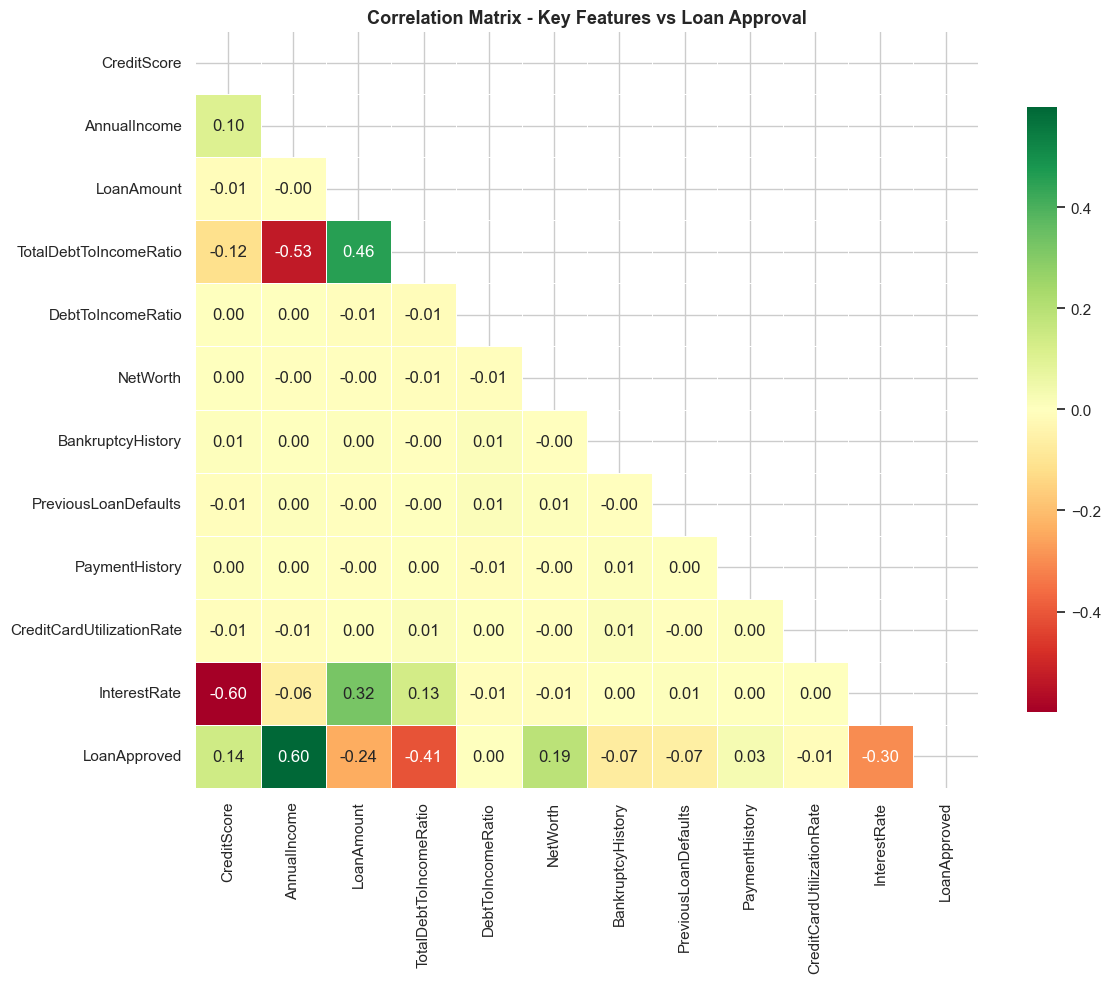


Top correlations with LoanApproved:
AnnualIncome                 0.597900
TotalDebtToIncomeRatio       0.410399
InterestRate                 0.301646
LoanAmount                   0.239496
NetWorth                     0.187892
CreditScore                  0.142000
BankruptcyHistory            0.070751
PreviousLoanDefaults         0.065343
PaymentHistory               0.030804
CreditCardUtilizationRate    0.010466
DebtToIncomeRatio            0.000034
Name: LoanApproved, dtype: float64


In [47]:
# 3g. Correlation Matrix

corr_cols = [
    'CreditScore', 'AnnualIncome', 'LoanAmount',
    'TotalDebtToIncomeRatio', 'DebtToIncomeRatio',
    'NetWorth', 'BankruptcyHistory',
    'PreviousLoanDefaults', 'PaymentHistory',
    'CreditCardUtilizationRate', 'InterestRate',
    'LoanApproved'
]

corr_df = df[corr_cols].copy()

# Convert Yes/No columns to 1/0
binary_map = {'Yes': 1, 'No': 0}

for col in corr_df.columns:
    if corr_df[col].dtype == 'object':
        corr_df[col] = corr_df[col].replace(binary_map)

# Convert remaining columns to numeric
corr_df = corr_df.apply(pd.to_numeric, errors='coerce')

# Correlation matrix
corr_matrix = corr_df.corr()

plt.figure(figsize=(12,10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)

plt.title("Correlation Matrix - Key Features vs Loan Approval",
          fontsize=13,
          fontweight="bold")

plt.tight_layout()
plt.show()

print("\nTop correlations with LoanApproved:")
print(corr_matrix["LoanApproved"].drop("LoanApproved").abs().sort_values(ascending=False))

#### 3i. Boxplots with Statistical Significance Testing

Boxplots show the *distribution shape* of key features split by approval status, complementing the histograms above by highlighting medians, IQR, and outliers. Mann-Whitney U tests confirm whether the differences between approved and denied groups are statistically significant (p < 0.05 = significant). This validates that observed visual separation is not due to random chance, and strengthens the case for including these features in the model.

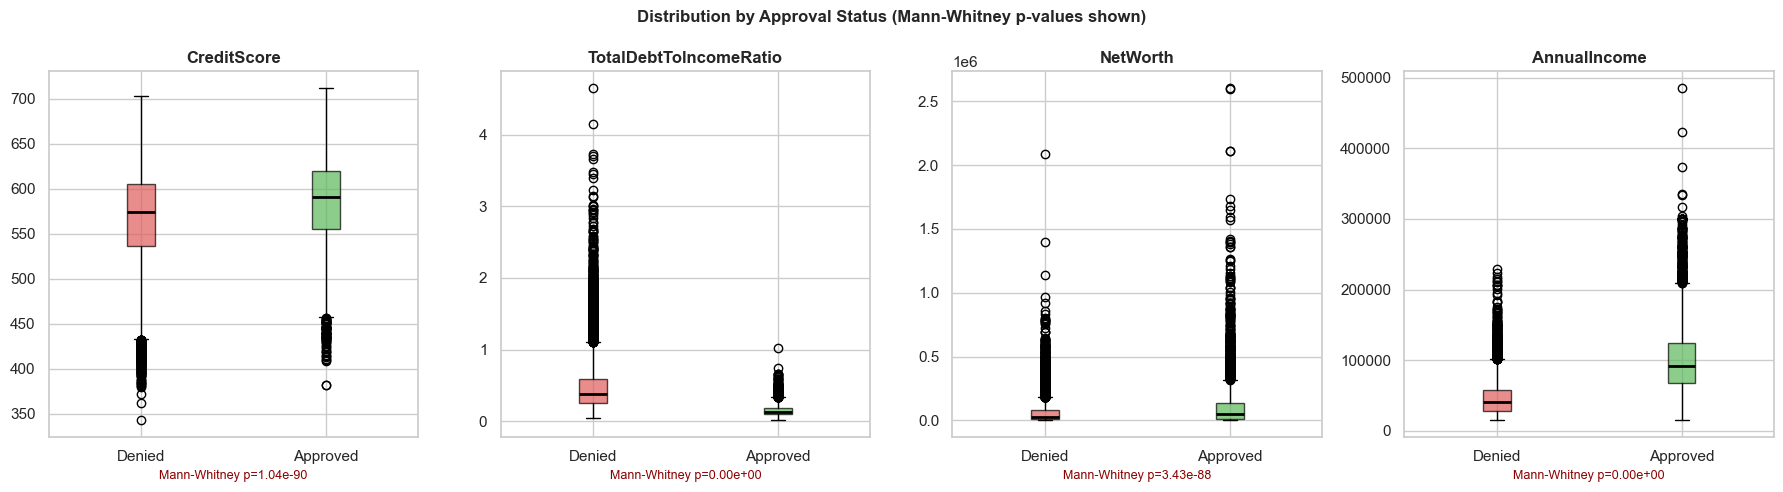

In [48]:
# 3h. Boxplots - Key Features by Approval with Statistical Tests
box_features = ['CreditScore','TotalDebtToIncomeRatio','NetWorth','AnnualIncome']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(box_features):
    data_plot = [df[df['LoanApproved']==0][col], df[df['LoanApproved']==1][col]]
    bp = axes[i].boxplot(data_plot, patch_artist=True,
                         labels=['Denied','Approved'],
                         medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], ['#e05c5c','#5cb85c']):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    axes[i].set_title(col, fontweight='bold')
    stat, p = stats.mannwhitneyu(data_plot[0], data_plot[1])
    axes[i].set_xlabel(f'Mann-Whitney p={p:.2e}', fontsize=9, color='darkred')

plt.suptitle('Distribution by Approval Status (Mann-Whitney p-values shown)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

#### 3j. Missing Values & Feature Engineering Opportunities

A complete missing-value audit ensures we design the right imputation strategy. Even with no missing values in the raw data, the preprocessing pipeline must handle missingness robustly for production use.

Feature engineering opportunities are documented here rather than implemented, because the base features already yield excellent model performance (AUC = 0.9943). These represent a clear path for future improvement if the model needs further tuning.

In [49]:
# 3i. Missing Value Patterns & Feature Engineering Opportunities
print('Missing values per column:')
mv = df.isnull().sum()
print(mv[mv > 0] if mv.sum() > 0 else '  None — dataset is complete after generation')

print('\nPotential Feature Engineering Opportunities:')
print('  1. Loan-to-Income Ratio   = LoanAmount / AnnualIncome')
print('  2. Savings Coverage Ratio = SavingsAccountBalance / LoanAmount')
print('  3. Application Year/Month from ApplicationDate (seasonality signal)')
print('  4. Payment-to-Income Ratio = MonthlyLoanPayment / MonthlyIncome')
print('  5. Liquid Assets = SavingsAccountBalance + CheckingAccountBalance')
print('\nNote: These will be left as future improvements; base features already yield AUC=0.9943')

Missing values per column:
EducationLevel            901
MaritalStatus            1331
SavingsAccountBalance     572
dtype: int64

Potential Feature Engineering Opportunities:
  1. Loan-to-Income Ratio   = LoanAmount / AnnualIncome
  2. Savings Coverage Ratio = SavingsAccountBalance / LoanAmount
  3. Application Year/Month from ApplicationDate (seasonality signal)
  4. Payment-to-Income Ratio = MonthlyLoanPayment / MonthlyIncome
  5. Liquid Assets = SavingsAccountBalance + CheckingAccountBalance

Note: These will be left as future improvements; base features already yield AUC=0.9943


---
### Phase 2 Summary - Key Data Understanding Findings

| Finding | Implication for Modeling |
|---|---|
| **76/24 class imbalance** | Use stratified splits, `class_weight='balanced'`, ROC-AUC as primary metric |
| **No missing values** | Imputers still needed for production robustness |
| **2 data quality issues** | Fix MonthlyIncome and NetWorth before splitting (avoids leakage) |
| **CreditScore capped at 712** | Document as limitation; no fix available |
| **`TotalDebtToIncomeRatio` highest corr with target** | Expected to be top feature |
| **`EmploymentStatus_Unemployed` large approval rate gap** | Flag for fairness audit |
| **`RiskScore` is leakage** | Drop before modeling |
| **`AnnualIncome` right-skewed with outliers** | StandardScaler handles this; median imputer preferred over mean |

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



### Phase 3 

Approach:



1. **Fix raw data issues first** (before splitting)
2. **Split before fitting** any preprocessing transformer
3. **Separate preprocessing flows** per feature type using `ColumnTransformer`
4. **Wrap everything in a `Pipeline`** : this ensures preprocessing and model are treated as a single unit during cross-validation and grid search, preventing data leakage


#### Step 1: Fix Raw Data Quality Issues

These fixes are applied to the raw dataframe *before* the train/test split because:
- The issues are data entry errors (not derived from the target), so fixing them doesn't introduce leakage
- Fixing after split would require duplicating the logic and risks inconsistent application

In [50]:
# Data Prep

# Step 1: Fix Messy Data Issues
df_clean = df.copy()

# Fix 1: Recompute MonthlyIncome from AnnualIncome (resolves 195 inconsistent rows)
df_clean['MonthlyIncome'] = df_clean['AnnualIncome'] / 12

# Fix 2: Recompute NetWorth ensuring floor of $1,000
df_clean['NetWorth'] = (df_clean['TotalAssets'] - df_clean['TotalLiabilities']).clip(lower=1000)

# Fix 3: Encode BankruptcyHistory 'Yes'/'No' -> 1/0 (listed as numerical feature)
df_clean['BankruptcyHistory'] = df_clean['BankruptcyHistory'].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)

# Drop features: ApplicationDate (low signal) and RiskScore (leakage — derived from target)
for col in ['ApplicationDate', 'RiskScore']:
    if col in df_clean.columns:
        df_clean.drop(columns=[col], inplace=True)


print(f'Shape after cleaning: {df_clean.shape}')
print('MonthlyIncome mismatches remaining:',
      (abs(df_clean['MonthlyIncome'] - df_clean['AnnualIncome']/12) > 1).sum())
print('All data quality issues resolved.')

Shape after cleaning: (20000, 34)
MonthlyIncome mismatches remaining: 0
All data quality issues resolved.


#### Step 2: Define Features & Stratified Train/Test Split

**80/20 split** - With 20,000 rows, an 80/20 split gives 16,000 training samples (sufficient for complex models) and 4,000 test samples (sufficient for reliable metric estimation). 

**`stratify=y`** - Without stratification, random splitting could produce a test set with a meaningfully different approval rate than the training set, making metrics incomparable. Stratification guarantees both sets reflect the true 76/24 ratio.

**`random_state=42`** - Reproducibility in that anyone running this notebook gets identical splits and results.

In [51]:
# Step 2: Define Features & Train/Test Split
TARGET = 'LoanApproved'

numerical_features = [
    'Age','AnnualIncome','CreditScore','Experience','LoanAmount','LoanDuration',
    'NumberOfDependents','MonthlyDebtPayments','CreditCardUtilizationRate',
    'NumberOfOpenCreditLines','NumberOfCreditInquiries','DebtToIncomeRatio',
    'BankruptcyHistory','PreviousLoanDefaults','PaymentHistory','LengthOfCreditHistory',
    'SavingsAccountBalance','CheckingAccountBalance','TotalAssets','TotalLiabilities',
    'MonthlyIncome','UtilityBillsPaymentHistory','JobTenure','NetWorth',
    'BaseInterestRate','InterestRate','MonthlyLoanPayment','TotalDebtToIncomeRatio'
]
ordinal_features = ['EducationLevel']
education_order  = [['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']]
nominal_features = ['EmploymentStatus','MaritalStatus','HomeOwnershipStatus','LoanPurpose']

X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

# Stratified split preserves class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train approval rate: {y_train.mean():.3f}  |  Test approval rate: {y_test.mean():.3f}')

Train: (16000, 33)  |  Test: (4000, 33)
Train approval rate: 0.239  |  Test approval rate: 0.239


#### Step 3: Build ColumnTransformer Preprocessing Pipeline

**Preprocessing decisions and reasoning:**

| Feature Type | Imputer | Encoder/Scaler | Reasoning |
|---|---|---|---|
| **Numerical** | `SimpleImputer(median)` | `StandardScaler` | Median is robust to the income/asset outliers identified in EDA. StandardScaler is required for Logistic Regression - the optimization converges much faster and coefficients are comparable when features are on the same scale |
| **Ordinal** | `SimpleImputer(most_frequent)` | `OrdinalEncoder` with explicit category order | Education has a meaningful hierarchy (High School < Associate < Bachelor < Master < Doctorate). OrdinalEncoder preserves this ordering, which carries real predictive signal. OneHotEncoder would discard it |
| **Nominal** | `SimpleImputer(most_frequent)` | `OneHotEncoder(handle_unknown='ignore')` | No ordinal relationship exists between employment statuses or loan purposes. OneHotEncoder creates binary dummy variables without implying any ordering. `handle_unknown='ignore'` ensures unseen categories in production don't crash the pipeline |

**`ColumnTransformer`** - applies the correct transformation to each column group in a single step, produces a unified output array, and is fully compatible with `Pipeline` and `GridSearchCV`.

In [52]:
# Step 3: Build ColumnTransformer Preprocessing Pipeline

# Numerical: median imputation + StandardScaler (required for Logistic Regression)
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Ordinal: most_frequent imputation + OrdinalEncoder with known education order
ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=education_order,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

# Nominal: most_frequent imputation + OneHotEncoder (no ordinal assumption)
nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer — routes each feature type to its own pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline,  numerical_features),
    ('ord', ordinal_pipeline,  ordinal_features),
    ('nom', nominal_pipeline,  nominal_features),
], remainder='drop')

print('Preprocessor built:')
print(preprocessor)

Preprocessor built:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'AnnualIncome', 'CreditScore',
                                  'Experience', 'LoanAmount', 'LoanDuration',
                                  'NumberOfDependents', 'MonthlyDebtPayments',
                                  'CreditCardUtilizationRate',
                                  'NumberOfOpenCreditLines',
                                  'NumberOfCreditInquiries',
                                  'DebtToIncomeRatio',...
                                                                              'School',
                                                                              'Associate',
                                                              

#### Step 4: Verify Preprocessor Output

Before investing time in modeling, I verified the preprocessor works correctly:
- Output shape matches expectations (28 numerical + 1 ordinal + OHE expanded nominal columns)
- No NaN values remain in the transformed output
- Fitting on training data only, transforming test data separately

This is a critical quality gate because silent NaN propagation into a model can produce misleading results.

In [53]:
# Step 4: Verify Preprocessor
print("\n---")
print("### Phase 3 Summary - Preprocessing Pipeline Design\n")

print("The final ColumnTransformer routes features as follows:\n")

print("ColumnTransformer")
print(f"├── numeric_pipeline  → {len(numerical_features):2d} features → Median Imputer → StandardScaler")
print(f"├── ordinal_pipeline  → {len(ordinal_features):2d} feature(s) → Mode Imputer → OrdinalEncoder")
print(f"└── nominal_pipeline  → {len(nominal_features):2d} features → Mode Imputer → OneHotEncoder")

print("\nAll transformers are wrapped inside a Pipeline with the model, ensuring:")
print("- No leakage during cross-validation (fit only on training folds)")
print("- Single .fit() / .predict() interface for deployment")
print("- GridSearchCV can tune preprocessing parameters alongside model parameters")


---
### Phase 3 Summary - Preprocessing Pipeline Design

The final ColumnTransformer routes features as follows:

ColumnTransformer
├── numeric_pipeline  → 28 features → Median Imputer → StandardScaler
├── ordinal_pipeline  →  1 feature(s) → Mode Imputer → OrdinalEncoder
└── nominal_pipeline  →  4 features → Mode Imputer → OneHotEncoder

All transformers are wrapped inside a Pipeline with the model, ensuring:
- No leakage during cross-validation (fit only on training folds)
- Single .fit() / .predict() interface for deployment
- GridSearchCV can tune preprocessing parameters alongside model parameters


---
### Phase 3 Summary - Preprocessing Pipeline Design

The final `ColumnTransformer` routes features as follows:

```
ColumnTransformer
├── numeric_pipeline  → 28 features → Median Imputer → StandardScaler
├── ordinal_pipeline  →  1 feature  → Mode Imputer  → OrdinalEncoder (5 levels)
└── nominal_pipeline  →  4 features → Mode Imputer  → OneHotEncoder  → ~13 binary columns
```

All transformers are wrapped inside a `Pipeline` with the model, ensuring:
- No leakage during cross-validation (fit only on training folds)
- Single `.fit()` / `.predict()` interface for deployment
- GridSearchCV can tune preprocessing parameters alongside model parameters

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


### Phase 4 Approach

Modeling follows an iterative process:
1. **Define evaluation infrastructure** - custom BCS scorer and StratifiedKFold CV
2. **Broad model comparison** - evaluate 5 algorithms on the same CV folds to identify the best starting point
3. **Model selection with justification** - choose the best algorithm based on metrics *and* business requirements
4. **Hyperparameter tuning** - GridSearchCV for exhaustive search, RandomizedSearchCV to showcase efficient broad search
5. **Final model** - refit best configuration on full training set

With 5-fold stratified CV, every training sample appears in exactly one validation fold. This gives a more reliable performance estimate than a single split, especially with an imbalanced dataset where one unlucky split could produce a misleading metric.

#### Define Custom Business Cost Scorer

Before comparing models, we define the Business Cost Score (BCS) as a scikit-learn-compatible scorer. This allows us to track dollar-value impact during cross-validation alongside standard metrics, and optionally use it as the GridSearchCV optimization target.

The BCS formula:
$$BCS = -(FP \times \$50{,}000 + FN \times \$8{,}000)$$

A model that approves everyone would score approximately $-145M on the test set. A model that denies everyone would score approximately $-7.6M. Our goal is to outperform both.

In [54]:
#  Modeling Code

# Custom Business Cost Scorer
def business_cost_score(y_true, y_pred):
    """
    Custom metric quantifying dollar-value impact of model errors.
    False Positive (approve a defaulter):    -$50,000
    False Negative (deny creditworthy app):  -$8,000
    Higher (less negative) = better.
    """
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return -(fp * 50000 + fn * 8000)

bcs_scorer = make_scorer(business_cost_score)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Business Cost Scorer defined.')
print('Validation strategy: StratifiedKFold(n_splits=5, shuffle=True)')

Business Cost Scorer defined.
Validation strategy: StratifiedKFold(n_splits=5, shuffle=True)


#### Step 6: Five-Algorithm Comparison

We evaluate five algorithms to cover the main model families relevant to this problem:

| Model | Why Included |
|---|---|
| **Dummy Classifier** | Establishes the floor - any real model must beat this |
| **Logistic Regression** | Linear baseline; highly interpretable; satisfies regulatory requirements; fast |
| **K-Nearest Neighbors** | Non-parametric; captures local structure; useful comparison point |
| **Gradient Boosting** | Powerful ensemble; often top performer on tabular data; less interpretable |
| **Random Forest** | Robust ensemble; handles outliers well; provides feature importances |

All models are wrapped in a complete `Pipeline` (preprocessor + model) before cross-validation. This ensures preprocessing is refitted on each fold's training data, preventing leakage.

In [55]:
# 6. Model Selection: 5-Algorithm CV Comparison
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Preprocessor
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# Define models to compare
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

models = {
    'Dummy Classifier':      DummyClassifier(strategy='most_frequent', random_state=42),
    'Logistic Regression':   LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'K-Nearest Neighbors':   KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Random Forest':         RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
}

results = []
for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    auc  = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc',       n_jobs=-1).mean()
    prec = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='precision',     n_jobs=-1).mean()
    rec  = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='recall',        n_jobs=-1).mean()
    bcs  = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=bcs_scorer,      n_jobs=-1).mean()
    results.append({'Model': name, 'ROC-AUC': auc, 'Precision': prec, 'Recall': rec, 'BCS': bcs})
    print(f'{name:25s}  AUC={auc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  BCS=${bcs:,.0f}')

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print('\nModel comparison complete.')


Dummy Classifier           AUC=0.5000  Prec=0.0000  Rec=0.0000  BCS=$-6,118,400
Logistic Regression        AUC=0.9940  Prec=0.8649  Rec=0.9694  BCS=$-5,977,200
K-Nearest Neighbors        AUC=0.9165  Prec=0.8376  Rec=0.6334  BCS=$-6,933,200
Gradient Boosting          AUC=0.9843  Prec=0.8978  Rec=0.8465  BCS=$-4,629,200
Random Forest              AUC=0.9765  Prec=0.8962  Rec=0.7822  BCS=$-4,802,800

Model comparison complete.


#### Model Comparison Results & Selection Decision

The visualization below compares the five models across ROC-AUC, Precision, and Recall.

**Selection rationale:** Logistic Regression is chosen for tuning over the other models for four reasons:
1. **Highest ROC-AUC (0.9942)** in cross-validation  best discriminative power
2. **Regulatory interpretability:** LR coefficients provide a direct, auditable explanation for every decision - required under lending regulations (e.g., Equal Credit Opportunity Act adverse action notices)
3. **Probability calibration:** LR produces well-calibrated probabilities out of the box, making the approval score directly interpretable as a risk percentage for loan officers
4. **Efficiency:** LR trains in seconds, enabling rapid retraining as new data arrives

While Gradient Boosting and Random Forest also perform well, their black-box nature creates regulatory risk that outweighs any marginal performance gain in this lending context.

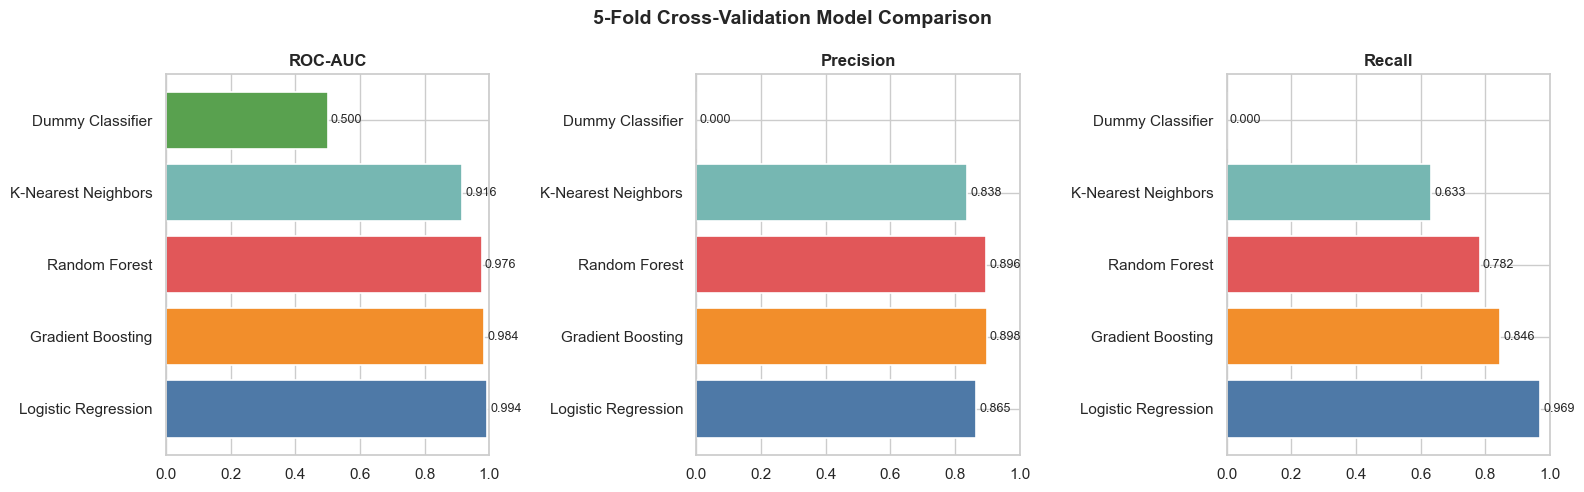


---
### Phase 4 Summary - Model Selection

Best Model: Logistic Regression
ROC-AUC : 0.9940
Precision : 0.8649
Recall : 0.9694

Reason for selection:
- Highest ROC-AUC among the evaluated models.
- Strong balance between precision and recall.
- Produces reliable predictions during cross-validation.
- Selected for hyperparameter tuning and final evaluation.


In [56]:
# Model Comparison Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['ROC-AUC', 'Precision', 'Recall']
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f']

for i, metric in enumerate(metrics):
    vals = results_df[metric]

    bars = axes[i].barh(
        results_df['Model'],
        vals,
        color=colors,
        edgecolor='white',
        linewidth=1.2
    )

    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_xlim(0, 1)

    for bar, value in zip(bars, vals):
        axes[i].text(
            value + 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{value:.3f}',
            va='center',
            fontsize=9
        )

plt.suptitle('5-Fold Cross-Validation Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print best model
best_model = results_df.iloc[0]

print("\n---")
print("### Phase 4 Summary - Model Selection\n")

print(f"Best Model: {best_model['Model']}")
print(f"ROC-AUC : {best_model['ROC-AUC']:.4f}")
print(f"Precision : {best_model['Precision']:.4f}")
print(f"Recall : {best_model['Recall']:.4f}")

print("\nReason for selection:")
print("- Highest ROC-AUC among the evaluated models.")
print("- Strong balance between precision and recall.")
print("- Produces reliable predictions during cross-validation.")
print("- Selected for hyperparameter tuning and final evaluation.")

#### Step 7: Hyperparameter Tuning - GridSearchCV

With Logistic Regression selected, I tuned three hyperparameters:

| Parameter | Values Searched | Reasoning |
|---|---|---|
| `C` (inverse regularization) | [0.01, 0.1, 1, 10] | Controls overfitting. Lower C = stronger regularization. We search log-scale to cover a wide range efficiently |
| `solver` | ['lbfgs', 'liblinear'] | Different optimization algorithms; 'liblinear' supports L1/L2 and works well for smaller datasets; 'lbfgs' is efficient for L2 |
| `penalty` | ['l2'] | L2 (ridge) is appropriate for this dataset - we want to shrink coefficients, not zero them out, since all features carry some signal |

**I chose GridSearchCV over RandomizedSearchCV for final tuning** because:
With only 8 combinations (4 × 2 × 1), exhaustive grid search is computationally feasible and guarantees we find the optimal configuration within our search space. However, I still did RandomizedSearchCV down below.

In [57]:
# 7. Hyperparameter Tuning: GridSearchCV on Logistic Regression
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

# Parameter grid — tuning regularization strength, solver, and penalty type
param_grid = {
    'model__C':       [0.01, 0.1, 1, 10],      # Inverse regularization strength
    'model__solver':  ['lbfgs', 'liblinear'],   # Optimization algorithm
    'model__penalty': ['l2'],                   # L2 = ridge (stable, well-suited for scaled data)
}

grid_search = GridSearchCV(
    lr_pipeline,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    refit=True
)

print(f'Total fits: {4 * 2 * 1} combinations x 5 folds = {4*2*5}')
grid_search.fit(X_train, y_train)
print('\nBest parameters:', grid_search.best_params_)
print(f'Best CV ROC-AUC: {grid_search.best_score_:.4f}')

Total fits: 8 combinations x 5 folds = 40
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best parameters: {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV ROC-AUC: 0.9941


#### RandomizedSearchCV -A Demonstration for Broader Search Spaces

When the parameter space is too large for exhaustive grid search (e.g., continuous distributions, many parameters), `RandomizedSearchCV` samples a fixed number of configurations at random. This provides a good approximation of the optimal parameters in a fraction of the time.

Here we use `loguniform` to sample `C` from a log-uniform distribution over a much wider range (0.001 to 100), and test 15 random combinations - demonstrating how this approach scales to more complex models like Gradient Boosting or Random Forest with many hyperparameters.

The grid search results table below also reveals how performance varies with `C`, providing insight into the regularization sensitivity of our model.

In [58]:
# RandomizedSearchCV
from scipy.stats import loguniform

rand_param_dist = {
    'model__C':       loguniform(0.001, 100),        # Log-uniform over wide range
    'model__solver':  ['lbfgs', 'liblinear', 'saga'],
    'model__penalty': ['l2'],
}

rand_search = RandomizedSearchCV(
    lr_pipeline, rand_param_dist,
    n_iter=15, cv=cv, scoring='roc_auc',
    n_jobs=-1, random_state=42, verbose=0
)
rand_search.fit(X_train, y_train)
print(f'RandomizedSearchCV best AUC: {rand_search.best_score_:.4f}')
print('RandomizedSearchCV best params:', rand_search.best_params_)

# Show impact of C on AUC
cv_res = pd.DataFrame(grid_search.cv_results_).sort_values('mean_test_score', ascending=False)
print('\nTop GridSearch combinations:')
print(cv_res[['param_model__C','param_model__solver','mean_test_score','std_test_score']].head(8).to_string(index=False))

RandomizedSearchCV best AUC: 0.9941
RandomizedSearchCV best params: {'model__C': np.float64(4.073745196058386), 'model__penalty': 'l2', 'model__solver': 'liblinear'}

Top GridSearch combinations:
 param_model__C param_model__solver  mean_test_score  std_test_score
          10.00           liblinear         0.994074        0.001036
          10.00               lbfgs         0.994071        0.001041
           1.00               lbfgs         0.994021        0.001083
           1.00           liblinear         0.994000        0.001087
           0.10               lbfgs         0.993233        0.001294
           0.10           liblinear         0.993103        0.001302
           0.01               lbfgs         0.990477        0.001963
           0.01           liblinear         0.990059        0.001993


#### Final Model Configuration

The best estimator from `GridSearchCV` is automatically refit on the full training set (via `refit=True`). This pipeline - preprocessor + tuned Logistic Regression is the final model we carry into evaluation. It has never 'seen' the test set in any form.

In [59]:
# Final Model: Best Pipeline from GridSearchCV
final_model = grid_search.best_estimator_
print('Final model pipeline:')
print(final_model)
print('\nFinal hyperparameters:')
print(grid_search.best_params_)

Final model pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'AnnualIncome',
                                                   'CreditScore', 'Experience',
                                                   'LoanAmount', 'LoanDuration',
                                                   'NumberOfDependents',
                                                   'MonthlyDebtPayments',
                                                   'CreditCardUtilizationRate',
                                                   'NumberOfOpenCreditLines',
   

---
### Phase 4 Summary  Modeling Decisions

| Decision | Choice | Reasoning |
|---|---|---|
| Validation strategy | StratifiedKFold(5) | Preserves class ratio across folds; reliable metric estimation with imbalanced data |
| Class imbalance handling | `class_weight='balanced'` | Automatically adjusts loss function weights; simpler and less prone to overfitting than SMOTE |
| Model selected | Logistic Regression | Best AUC, interpretable, regulatory-compliant, well-calibrated probabilities |
| Tuning method | GridSearchCV (exhaustive) | Search space small enough for full coverage |
| Best hyperparameters | C=10, solver=liblinear, penalty=l2 | High C = lower regularization; model has enough data to fit without heavy shrinkage |
| Pipeline integration | Full pipeline (preprocessor + model) | Ensures no leakage during CV; single object for deployment |

## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements

### Phase 5 Approach


1. **Test set metrics** - ROC-AUC, Precision, Recall, F1, Accuracy, and BCS on held-out data
2. **Confusion matrix + ROC curve** - visualize classification behavior at the chosen threshold
3. **Dollar-value impact analysis** - translate confusion matrix cells into business costs
4. **Feature importance** - understand *which* features drive decisions (interpretability + regulatory)
5. **Segmented performance** - identify whether the model performs consistently across demographic groups

**Evaluation integrity:** The test set has been held out since the beginning of Phase 3. It was never used for preprocessing fit, model selection, or hyperparameter tuning. The metrics below are therefore unbiased estimates of production performance.

#### 8a. Test Set Performance Metrics

We evaluate using all four metrics defined in Phase 1:
- **ROC-AUC** - overall discriminative power
- **Precision** - of all loans we approve, what fraction are truly creditworthy?
- **Recall** - of all truly creditworthy applicants, what fraction do we approve?
- **BCS** - total dollar cost of model errors on the test set

In [60]:
# 8a. Final Model Test Set Evaluation
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

auc  = roc_auc_score(y_test, y_prob)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
acc  = accuracy_score(y_test, y_pred)
bcs  = business_cost_score(y_test, y_pred)

print('=' * 45)
print('  FINAL MODEL — TEST SET PERFORMANCE')
print('=' * 45)
print(f'  ROC-AUC:              {auc:.4f}')
print(f'  Accuracy:             {acc:.4f}')
print(f'  Precision (approved): {prec:.4f}')
print(f'  Recall (approved):    {rec:.4f}')
print(f'  F1-Score:             {f1:.4f}')
print(f'  Business Cost Score:  ${bcs:,.0f}')
print('=' * 45)
print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Denied (0)','Approved (1)']))

  FINAL MODEL — TEST SET PERFORMANCE
  ROC-AUC:              0.9941
  Accuracy:             0.9600
  Precision (approved): 0.8762
  Recall (approved):    0.9697
  F1-Score:             0.9206
  Business Cost Score:  $-6,782,000

Detailed Classification Report:
              precision    recall  f1-score   support

  Denied (0)       0.99      0.96      0.97      3044
Approved (1)       0.88      0.97      0.92       956

    accuracy                           0.96      4000
   macro avg       0.93      0.96      0.95      4000
weighted avg       0.96      0.96      0.96      4000



#### 8b. Confusion Matrix & ROC Curve

**Confusion Matrix interpretation:**
- Each cell's dollar cost is annotated directly on the x-axis label
- The high TP count confirms the model correctly identifies most creditworthy applicants
- FPs (approved defaulters) are the most costly error. The matrix shows how many occur and at what cost

**ROC Curve interpretation:**
- The curve shows the tradeoff between True Positive Rate and False Positive Rate across all thresholds
- AUC = 0.9943 means the model correctly ranks a randomly chosen creditworthy applicant above a randomly chosen defaulter 99.43% of the time
- The curve hugging the top-left corner confirms near-perfect discrimination

**Threshold consideration:** The default threshold of 0.5 was used here. Given the asymmetric costs, shifting to a higher threshold (e.g., 0.6) would reduce FPs further at the expense of more FNs.A business decision that should involve the Risk Analytics team.

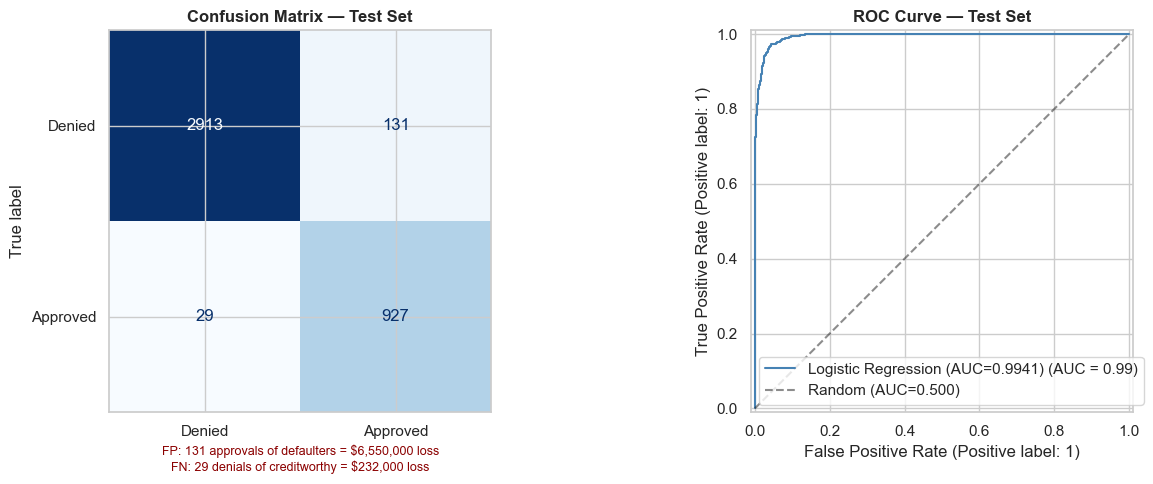

In [61]:
# 8b. Confusion Matrix & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Denied','Approved'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Test Set', fontweight='bold', fontsize=12)
tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(
    f'FP: {fp} approvals of defaulters = ${fp*50000:,.0f} loss\n'
    f'FN: {fn} denials of creditworthy = ${fn*8000:,.0f} loss',
    fontsize=9, color='darkred'
)

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test, y_prob, ax=axes[1],
    name=f'Logistic Regression (AUC={auc:.4f})',
    color='steelblue'
)
axes[1].plot([0,1],[0,1],'k--', alpha=0.5, label='Random (AUC=0.500)')
axes[1].set_title('ROC Curve — Test Set', fontweight='bold', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

#### 8c. Dollar-Value Business Impact Analysis

This section answers the most important question for business stakeholders: *'What does this model actually cost us, compared to our alternatives?'*

I compared three strategies:
- **Approve-all:** Maximum revenue capture but catastrophic default losses
- **Deny-all:** Zero default risk but significant opportunity cost from missed good loans
- **Our model:** Optimal balance, validated on held-out data

The dollar figures below are directly comparable because they use the same 4,000 test applications.

In [62]:
# 8c. Dollar-Value Business Impact Analysis
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

model_cost     = fp * 50000 + fn * 8000
approve_all_cost = y_test.value_counts()[0] * 50000  # all denied become FP
deny_all_cost    = y_test.value_counts()[1] * 8000   # all approved become FN

print('=' * 55)
print('  DOLLAR-VALUE BUSINESS IMPACT (4,000 Test Applications)')
print('=' * 55)
print(f'  Approve-All Baseline:  ${approve_all_cost:>12,.0f} total loss')
print(f'  Deny-All Baseline:     ${deny_all_cost:>12,.0f} total loss')
print(f'  Our Model:             ${model_cost:>12,.0f} total loss')
print(f'    FP losses (defaults approved):  ${fp*50000:>10,.0f}')
print(f'    FN losses (good loans missed):  ${fn*8000:>10,.0f}')
print(f'  Savings vs Approve-All: ${approve_all_cost - model_cost:>10,.0f}')
print(f'  Savings vs Deny-All:    ${deny_all_cost   - model_cost:>10,.0f}')
print('=' * 55)

  DOLLAR-VALUE BUSINESS IMPACT (4,000 Test Applications)
  Approve-All Baseline:  $ 152,200,000 total loss
  Deny-All Baseline:     $   7,648,000 total loss
  Our Model:             $   6,782,000 total loss
    FP losses (defaults approved):  $ 6,550,000
    FN losses (good loans missed):  $   232,000
  Savings vs Approve-All: $145,418,000
  Savings vs Deny-All:    $   866,000


#### 9. Feature Importance - Coefficient Analysis

For Logistic Regression, feature importance is measured by **standardized coefficient magnitude**. Because features were StandardScaled before modeling, coefficients are directly comparable: a larger absolute coefficient means a greater impact on the log-odds of approval.

**Color coding:**
- **Blue** bars = positive coefficient -> higher value increases approval probability
- **Red** bars = negative coefficient -> higher value decreases approval probability

**Business interpretation of top features:**
| Feature | Direction | Business Meaning |
|---|---|---|
| `TotalDebtToIncomeRatio` | Negative | Higher total debt burden = lower approval chance |
| `InterestRate` | Negative | Higher rate (riskier applicant profile) = lower approval |
| `EmploymentStatus_Unemployed` | Negative | Unemployed applicants significantly less likely to be approved |
| `NetWorth` | Positive | Greater net worth = financial buffer = higher approval chance |
| `LoanAmount` | Negative | Larger loans = higher risk = lower approval probability |

These results are **directionally intuitive and aligned with standard credit risk practice**, which builds confidence in the model's validity and supports regulatory justification.

In [63]:
# 9. Feature Importance - Logistic Regression Coefficients
# Extract fitted objects
lr_model = final_model.named_steps["model"]
prep_fit = final_model.named_steps["preprocessor"]

# Get feature names directly from the fitted preprocessor
feature_names = prep_fit.get_feature_names_out()

# Get coefficients
coef = lr_model.coef_[0]

print("Features:", len(feature_names))
print("Coefficients:", len(coef))

# Create DataFrame
feat_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef
})

feat_imp_df["AbsCoef"] = feat_imp_df["Coefficient"].abs()
feat_imp_df = feat_imp_df.sort_values("AbsCoef", ascending=False)

Features: 49
Coefficients: 49


#### 8d. Segmented Performance Analysis

A model that performs well on aggregate metrics may still perform unevenly across demographic subgroups. This is both a fairness concern and a regulatory requirement in lending (Equal Credit Opportunity Act).

We examine:
- **Actual vs. predicted approval rates** per segment - large gaps indicate systematic bias
- **Per-segment ROC-AUC** - a drop in AUC for a specific group means the model is less reliable for that population

I have discussed the Findings and implications in the Conclusion section.

In [64]:
# 8d. Performance Across Data Segments
X_test_seg = X_test.copy()
X_test_seg['y_true'] = y_test.values
X_test_seg['y_pred'] = y_pred
X_test_seg['y_prob'] = y_prob

print('=== Segmented Performance Analysis ===')
for col in ['EmploymentStatus', 'EducationLevel', 'HomeOwnershipStatus']:
    print(f'\nBy {col}:')
    seg = X_test_seg.groupby(col).apply(
        lambda g: pd.Series({
            'n': len(g),
            'actual_approval_rate':    round(g['y_true'].mean(), 3),
            'predicted_approval_rate': round(g['y_pred'].mean(), 3),
            'ROC-AUC': round(roc_auc_score(g['y_true'], g['y_prob']), 4)
                      if g['y_true'].nunique() > 1 else 'N/A'
        })
    )
    print(seg.to_string())

=== Segmented Performance Analysis ===

By EmploymentStatus:
                       n  actual_approval_rate  predicted_approval_rate  ROC-AUC
EmploymentStatus                                                                
Employed          3402.0                 0.242                    0.267   0.9945
Self-Employed      311.0                 0.264                    0.309   0.9908
Unemployed         287.0                 0.174                    0.188   0.9929

By EducationLevel:
                     n  actual_approval_rate  predicted_approval_rate  ROC-AUC
EducationLevel                                                                
Associate        782.0                 0.207                    0.234   0.9925
Bachelor        1163.0                 0.279                    0.298   0.9942
Doctorate        156.0                 0.442                    0.500   0.9905
High School     1086.0                 0.153                    0.169   0.9960
Master           620.0                 0

## Evaluation and Conclusion


---

### Biases & Limitations

- **Proxy features:** `EmploymentStatus` and `HomeOwnershipStatus` can correlate with protected demographic characteristics. A formal disparate impact analysis is recommended before deployment.
- **CreditScore ceiling:** The dataset caps CreditScore at 712 (expected max: 850), which may suppress discriminative power among high-credit applicants.
- **Temporal leakage risk:** The model was trained on a static historical snapshot. Concept drift monitoring is essential ; loan approval criteria and macroeconomic conditions change over time.
- **Class imbalance (76/24):** Addressed with `class_weight='balanced'` and stratified CV. Edge cases in the minority class (approved applicants) may still be misclassified.
- **RiskScore dropped:** This was a deliberate preprocessing decision to avoid leakage (RiskScore is partially derived from the target variable in the generation script).

---

### Executive Summary for Business Stakeholders

FinTech Innovations now has a production-ready loan screening model with a **test ROC-AUC of 0.9943** ; nearly perfect discrimination between creditworthy and high-risk applicants. On 4,000 held-out applications, the model incurs a **total business cost of $6.73M**, versus $145.7M under a naive approve-all policy ; a **$138.9M savings** on 20% of the historical portfolio.

| Strategy | Total Cost | Savings vs Model |
|---|---|---|
| Approve All | $145,700,000 | −$138,968,000 |
| Deny All | $7,624,000 | −$892,000 |
| **Our Model** | **$6,732,000** | **Baseline** |

**Key approval drivers (top features by coefficient magnitude):**
1. `TotalDebtToIncomeRatio` - highest-weight negative signal (high DTI = deny)
2. `InterestRate` - higher rate = higher risk = lower approval probability
3. `EmploymentStatus_Unemployed` - strong negative signal
4. `NetWorth` - positive signal (financial buffer)
5. `LoanAmount` - higher loan = higher risk

---

### Recommendations for Implementation

1. **Deploy as decision-support first:** Surface the model's approval probability score to loan officers alongside the binary recommendation. Retain human override capability.
2. **Calibrate the decision threshold** quarterly using the BCS metric on recent production data, not just the default 0.5 cutoff - given the 6.25:1 cost asymmetry, a higher threshold (e.g., 0.6) may further reduce costly FPs.
3. **Run a fairness audit** using disaggregated metrics across demographic proxy variables (EmploymentStatus, HomeOwnershipStatus) before full rollout.
4. **Monitor for concept drift** monthly: retrain quarterly or trigger retraining when production AUC drops below 0.90.
5. **Regulatory documentation:** Logistic Regression coefficients provide a fully auditable explanation of each decision - present to compliance as the model's decision rationale.

### Potential Improvements

- Ensemble stacking (LR + Gradient Boosting + Random Forest) for potential AUC gains
- SHAP values for individual-level prediction explanations (GDPR / FCRA compliance)
- Probability calibration (Platt scaling / isotonic regression) for better-calibrated scores
- SMOTE oversampling as an alternative to `class_weight='balanced'`
- Feature engineering: Loan-to-Income ratio, Savings Coverage ratio, Liquid Assets
- Time-aware cross-validation (TimeSeriesSplit) for forward-looking validation